In [1]:
import pandas
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

runs_dir = "/home/mark/projects/rosarl/scripts/runs/cluster/runs"

prop_cycle = plt.rcParams['axes.prop_cycle']
avail_colors = prop_cycle.by_key()['color']
colors = {
    "TRPO":avail_colors[3],
    "CPO":avail_colors[1],
    "TRPOLag":avail_colors[0],
    "TRPOMinmax":avail_colors[2],
    "TRPOSaute":avail_colors[4],
    "P3O": avail_colors[5],
}

In [2]:
def get_progress_files(runs_dir, algo_dir):
    directory = os.path.join(runs_dir, algo_dir)
    file_map = {}
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file == "progress.csv":
                root_dict = file_map.setdefault(root, {})
                # progress_files.append(os.path.join(root, file))
                root_dict["progress"] = os.path.join(root, file)
            elif file == "config.json":
                root_dict = file_map.setdefault(root, {})
                # config_files.append(os.path.join(root, file))
                root_dict["config"] = os.path.join(root, file)
    
    return file_map

In [3]:
def plot_algo(label, algo_dir, metric, axes, legend=False, num_epochs=None, num_envs_to_plot=None):
    result_files = get_progress_files(runs_dir, algo_dir)
    # assert len(result_files) == 10, f"{len(result_files)} files found for {label}."

    dfs = []
    for files in result_files.values():
        df = pandas.read_csv(files["progress"])
        config = json.load(files["config"])
        num_envs = config["train_cfgs"]["vector_env_nums"]
        if num_envs is None or num_envs == num_envs_to_plot:
            dfs.append(df)

    full_df = pandas.concat(dfs, axis=1, join="inner")

    # color = colors[label]

    renames = {
        "CumulativeAvgCost": "CumulativeAvgCost",
        "CumulativeCost": "CumulativeCost",
        "EpCost": "AverageEpCost",
        "EpRet": "AverageEpRet",
        "EpLen": "EpLen",
        "EpSuccess": "Success Rate",
    }

    renamed_metric = renames[metric]

    if num_epochs is not None:
        full_df = full_df[0:num_epochs]

    if metric == "CumulativeAvgCost":
        std = full_df[f"Metrics/EpCost"].cumsum(axis=0).std(axis=1)
        full_df[f"Metrics/EpCost"].cumsum(axis=0).mean(axis=1).rename(f"{label}").plot(ax=axes, xlabel="epoch", ylabel=renamed_metric, legend=legend)
    else:
        std = full_df[f"Metrics/{metric}"].std(axis=1)
        full_df[f"Metrics/{metric}"].mean(axis=1).rename(f"{label}").plot(ax=axes, xlabel="epoch", ylabel=renamed_metric, legend=legend)    


In [100]:
def plot_results(algos, algos_dirs, metrics_labels, chart_title=None, num_envs_to_plot=None, col_wrap=None):
    algos_dfs = []
    for algo, algo_dir in zip(algos, algos_dirs):
        result_files = get_progress_files(runs_dir, algo_dir)

        file_dfs = []
        for files in result_files.values():
            with open(files["config"], "r") as cf:
                config = json.load(cf)
            num_envs = config["train_cfgs"]["vector_env_nums"]

            if num_envs_to_plot is None or num_envs == num_envs_to_plot:
                if algo.endswith("Minmax"):
                    df = pandas.read_csv(
                        files["progress"],
                        usecols=metrics_labels + ["Misc/MinmaxPenalty"],
                    )
                else:
                    df = pandas.read_csv(files["progress"], usecols=metrics_labels)
                file_dfs.append(df)

        assert len(file_dfs) == 10, f"{len(file_dfs)} files found for {algo}."

        algo_df = pandas.concat(file_dfs, axis=1, join="inner")
        algo_df["algo"] = algo
        algo_df = pandas.melt(algo_df.reset_index(), id_vars=["index", "algo"])
        algos_dfs.append(algo_df)

    full_df = pandas.concat(algos_dfs)
    full_df["steps"] = (full_df["index"] + 1) * 30000

    chart = sns.relplot(
        data=full_df,
        x="steps",
        y="value",
        hue="algo",
        col="variable",
        kind="line",
        hue_order=algos,
        col_order=metrics_labels + ["Misc/MinmaxPenalty"],
        facet_kws={"sharey": False},
        legend=True,
        estimator="mean",
        errorbar="sd",
        col_wrap=col_wrap,
    )
    chart.set_axis_labels(x_var="Steps", y_var="")
    chart.set_titles(col_template="{col_name}")
    chart.tight_layout()
    if chart_title is not None:
        chart.figure.suptitle(chart_title, x=0.47, y=0.0, va="top")
    chart.legend.set_title(None)
    sns.move_legend(chart, "lower center", fontsize=14, ncols=len(algos), bbox_to_anchor=(0.47, 1.0))

    # TODO: legend stuff
    # how do we make the lines thicker for visibility?

    # leg = legax.legend(h, l, loc='center', ncol=5, handlelength=1.5,
    #        mode="expand", borderaxespad=0., prop={'size': 13})

In [5]:
figsize = (25, 5)

sns.set_theme(context="paper", style="darkgrid")

In [161]:
# def plot_results(algos, algos_dirs, metrics):
#     metrics_labels = [f"Metrics/{metric}" for metric in metrics]

#     algos_dfs = []
#     for algo, algo_dir in zip(algos, algos_dirs):
#         progress_files = get_progress_files(runs_dir, algo_dir)
#         assert len(progress_files) == 10, f"{len(progress_files)} files found for {algo}."
        
#         file_dfs = [pandas.read_csv(f, usecols=metrics_labels) for f in progress_files]

#         algo_df = pandas.concat(file_dfs, axis=1, join="inner")
#         algo_df["algo"] = algo
#         algo_df = pandas.melt(algo_df.reset_index(), id_vars=["index", "algo"])
#         algos_dfs.append(algo_df)

#     full_df = pandas.concat(algos_dfs)

#     renames = {
#         "CumulativeCost": "MeanCumulativeCost",
#         "EpCost": "MeanEpCost",
#         "EpRet": "MeanEpRet",
#         "EpLen": "MeanEpLen",
#         "EpSuccess": "MeanSuccessRate",
#     }

#     # labels = list(renames[metric] for metric in metrics)

#     gg = full_df.groupby(["variable", "algo", "index"]).mean()
#     gg = gg.reset_index()
#     gg["steps"] = (gg["index"]+1) * 30000

#     col_order = [f"Metrics/{metric}" for metric in metrics]

#     facetgrid = sns.relplot(data=gg, x="steps", y="value", hue="algo", col="variable", kind="line", hue_order=algos, col_order=col_order, facet_kws={"sharey": False}, legend=True)
#     facetgrid.set_axis_labels(x_var="Steps", y_var="")
#     facetgrid.set_titles(col_template="{col_name}")
#     facetgrid.legend.set_title(None)
#     # facetgrid.legend.set_ncols(len(algos))
#     # facetgrid.add_legend(legend_data=colors, label_order=algos, loc="upper center", ncol=len(algos), handlelength=1.5, bbox_to_anchor=(0, 1))

#             # leg = legax.legend(h, l, loc='center', ncol=5, handlelength=1.5,
#             #        mode="expand", borderaxespad=0., prop={'size': 13})

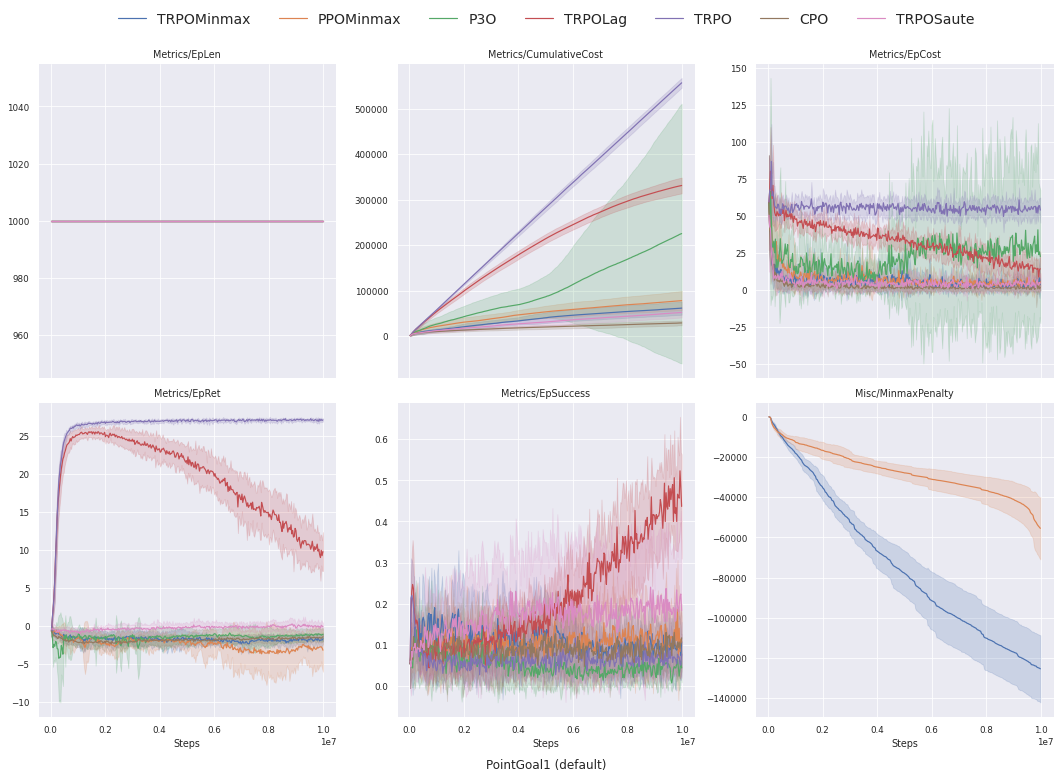

In [95]:
def build_dir(algo):
    return f"pointgoal1-default/{algo}-{{SafetyterminalnonePointGoal1-v0}}"

chart_title = "PointGoal1 (default)"
algos = [
    "TRPOMinmax",
    "PPOMinmax",
    "P3O",
    "TRPOLag",
    "TRPO",
    "CPO",
    "TRPOSaute"
]
algos_dirs = [build_dir(algo) for algo in algos]
metrics = ("EpLen", "CumulativeCost", "EpCost", "EpRet", "EpSuccess")
metrics_labels = [f"Metrics/{metric}" for metric in metrics]

plot_results(algos, algos_dirs, metrics_labels, chart_title=chart_title, num_envs_to_plot=None, col_wrap=3)


In [ ]:
# def build_dir(algo):
#     return f"pointgoal1-unsafe-terminal/{algo}-{{SafetyterminalPointGoal1-v0}}"

# algos = [
#     "TRPOMinmax",
#     "PPOMinmax",
#     "P3O",
#     "TRPOLag",
#     "TRPO",
#     "CPO",
#     "TRPOSaute"
# ]
# algos_dirs = [build_dir(algo) for algo in algos]
# metrics = ("EpLen", "CumulativeCost", "EpCost", "EpRet", "EpSuccess")
# metrics_labels = [f"Metrics/{metric}" for metric in metrics]

# plot_results(algos, algos_dirs, metrics_labels, num_envs_to_plot=10)

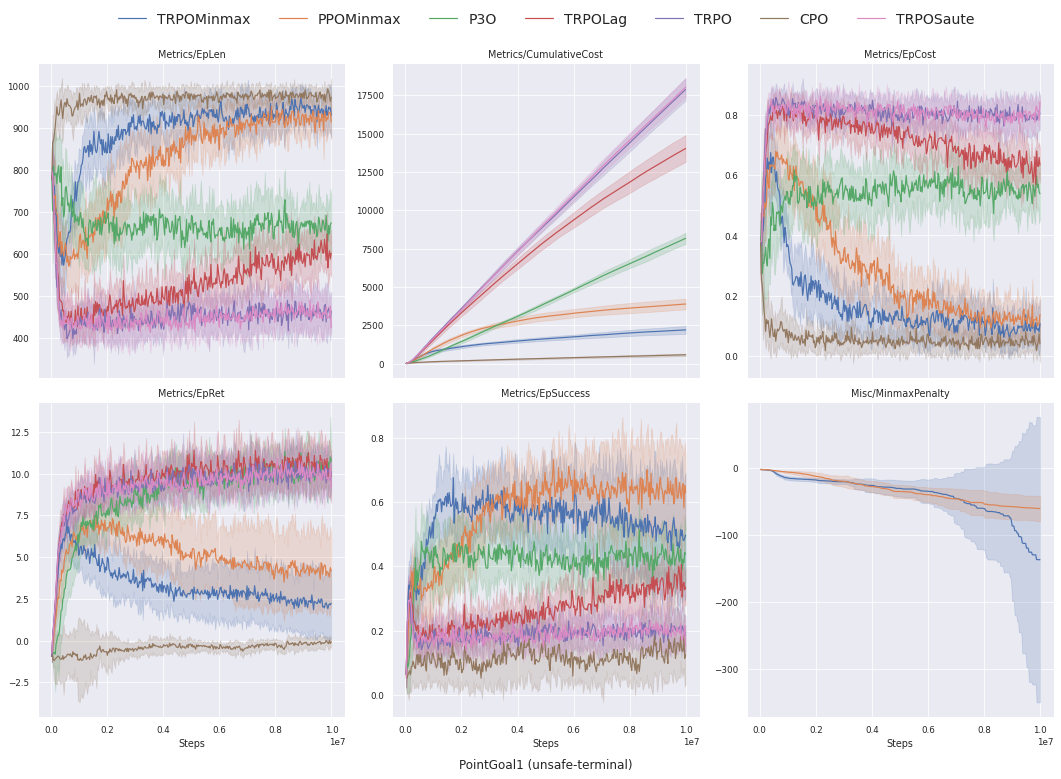

In [96]:
def build_dir(algo):
    return f"pointgoal1-unsafe-terminal/{algo}-{{SafetyterminalPointGoal1-v0}}"

chart_title = "PointGoal1 (unsafe-terminal)"
algos = [
    "TRPOMinmax",
    "PPOMinmax",
    "P3O",
    "TRPOLag",
    "TRPO",
    "CPO",
    "TRPOSaute"
]
algos_dirs = [build_dir(algo) for algo in algos]
metrics = ("EpLen", "CumulativeCost", "EpCost", "EpRet", "EpSuccess")
metrics_labels = [f"Metrics/{metric}" for metric in metrics]

plot_results(algos, algos_dirs, metrics_labels, chart_title=chart_title, num_envs_to_plot=1, col_wrap=3)

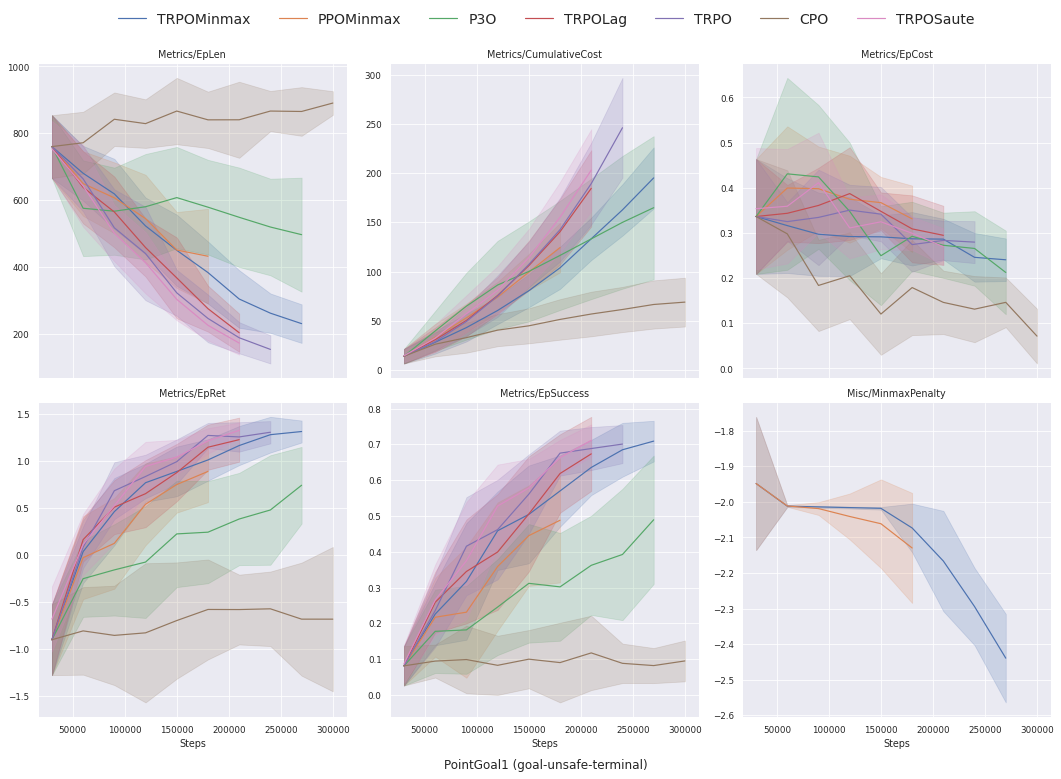

In [101]:
def build_dir(algo):
    return f"pointgoal1-goal-unsafe-terminal/{algo}-{{SafetyterminalgoalPointGoal1-v0}}"

chart_title = "PointGoal1 (goal-unsafe-terminal)"
algos = [
    "TRPOMinmax",
    "PPOMinmax",
    "P3O",
    "TRPOLag",
    "TRPO",
    "CPO",
    "TRPOSaute"
]
algos_dirs = [build_dir(algo) for algo in algos]
metrics = ("EpLen", "CumulativeCost", "EpCost", "EpRet", "EpSuccess")
metrics_labels = [f"Metrics/{metric}" for metric in metrics]

plot_results(algos, algos_dirs, metrics_labels, chart_title=chart_title, num_envs_to_plot=1, col_wrap=3)

In [ ]:
def build_dir(algo):
    return f"pointpush1-unsafe-terminal/{algo}-{{SafetyterminalPointPush1-v0}}"

algos = [
    "TRPOMinmax",
    "PPOMinmax",
    "P3O",
    "TRPOLag",
    "TRPO",
    "CPO",
    "TRPOSaute"
]
algos_dirs = [build_dir(algo) for algo in algos]
metrics = ("EpLen", "CumulativeCost", "EpCost", "EpRet", "EpSuccess")
metrics_labels = [f"Metrics/{metric}" for metric in metrics]

plot_results(algos, algos_dirs, metrics_labels, num_envs_to_plot=1, col_wrap=3)

In [ ]:
def build_dir(algo):
    return f"pointpush1-goal-unsafe-terminal/{algo}-{{SafetyterminalgoalPointPush1-v0}}"

algos = [
    "TRPOMinmax",
    "PPOMinmax",
    "P3O",
    "TRPOLag",
    "TRPO",
    "CPO",
    "TRPOSaute"
]
algos_dirs = [build_dir(algo) for algo in algos]
metrics = ("EpLen", "CumulativeCost", "EpCost", "EpRet", "EpSuccess")
metrics_labels = [f"Metrics/{metric}" for metric in metrics]

plot_results(algos, algos_dirs, metrics_labels, num_envs_to_plot=1, col_wrap=3)